**Comparative Analysis of AAPL, MSFT, TCS (2025)**
To analyse and compare the price performance, volatility, correlation, and risk-adjusted returns of Apple (AAPL), Microsoft (MSFT), and Tata Consultancy Services (TCS) over the 2025 calendar year using Python-based financial data analysis.


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
import yfinance as yf


ticker = "AAPL"
start_date = "2025-01-01"
end_date = "2026-01-01"


df = yf.download(ticker, start=start_date, end=end_date)


df.to_csv(f"{ticker}_historical_data.csv")


/tmp/ipykernel_1907/3375276931.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [57]:
df.head(5)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.301910,247.518580,240.284799,247.349646,55740700
2025-01-03,241.815018,242.629804,240.354349,241.815018,40244100
2025-01-06,243.444626,245.759836,241.656050,242.759004,45045600
2025-01-07,240.672333,243.991125,239.817792,241.437433,40856000
2025-01-08,241.159195,242.162793,238.526025,240.384148,37628900


In [58]:
df.shape

(250, 5)

In [59]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2025-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   250 non-null    float64
 1   (High, AAPL)    250 non-null    float64
 2   (Low, AAPL)     250 non-null    float64
 3   (Open, AAPL)    250 non-null    float64
 4   (Volume, AAPL)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


In [61]:
rolling_avg = df['Close']['AAPL'].rolling(window=30).mean()
print(rolling_avg)

Date
2025-01-02           NaN
2025-01-03           NaN
2025-01-06           NaN
2025-01-07           NaN
2025-01-08           NaN
                 ...    
2025-12-24    274.688321
2025-12-26    274.685991
2025-12-29    274.712943
2025-12-30    274.735233
2025-12-31    274.881627
Name: AAPL, Length: 250, dtype: float64


In [62]:
y = df['Close']['AAPL']
x = df.index

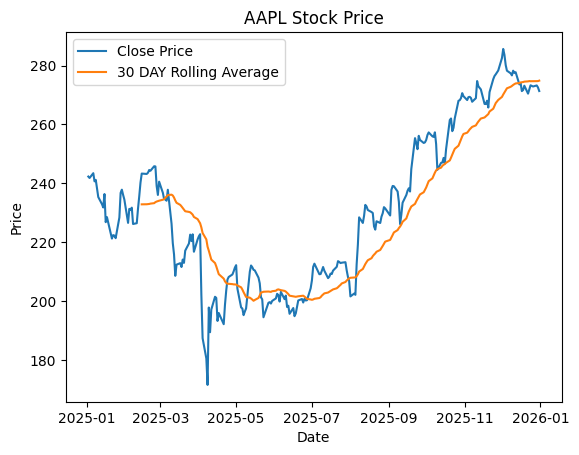

In [63]:
plt.plot(x, y, label='Close Price')
plt.plot(x,rolling_avg,label = '30 DAY Rolling Average')
plt.title('AAPL Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [64]:
low_date = df['Close']['AAPL'].idxmin()
high_date = df['Close']['AAPL'].idxmax()
print(low_date)
print(high_date)

2025-04-08 00:00:00
2025-12-02 00:00:00


In [65]:
low_price = df['Close']['AAPL'].min()
high_price = df['Close']['AAPL'].max()

In [71]:
pct_change = ((high_price - low_price) / low_price) * 100
print(round(pct_change,2))

66.55


In [67]:
print(f"Lowest close: {low_price:.2f} on {low_date.date()}")
print(f"Highest close: {high_price:.2f} on {high_date.date()}")
print(f"% change from low to high: {pct_change:.2f}%")

Lowest close: 171.51 on 2025-04-08
Highest close: 285.66 on 2025-12-02
% change from low to high: 66.55%


In [72]:
rolling_50 = df['Close']['AAPL'].rolling(window=50).mean()
print(rolling_50)

Date
2025-01-02           NaN
2025-01-03           NaN
2025-01-06           NaN
2025-01-07           NaN
2025-01-08           NaN
                 ...    
2025-12-24    270.452086
2025-12-26    270.937215
2025-12-29    271.467224
2025-12-30    271.887130
2025-12-31    272.084243
Name: AAPL, Length: 250, dtype: float64


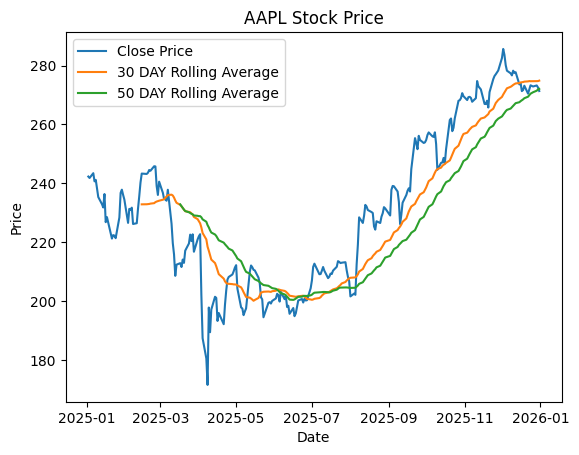

In [73]:
plt.plot(x, y, label='Close Price')
plt.plot(x,rolling_avg,label = '30 DAY Rolling Average')
plt.plot(x,rolling_50,label = '50 DAY Rolling Average')
plt.title('AAPL Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [74]:
stocks = pd.DataFrame({
    'date': ['2025-01-02','2025-01-03','2025-01-06',
             '2025-01-02','2025-01-03','2025-01-06'],
    'ticker': ['AAPL','AAPL','AAPL','MSFT','MSFT','MSFT'],
    'close_price': [242.30, 241.82, 243.44, 415.20, 418.75, 420.10]
})

info = pd.DataFrame({
    'ticker': ['AAPL','MSFT'],
    'company_name': ['Apple Inc','Microsoft Corp'],
    'sector': ['Technology','Technology']
})

In [75]:
merged_info = pd.merge(stocks,info, on = 'ticker')
merged_info

,date,ticker,close_price,company_name,sector
0,2025-01-02,AAPL,242.30,Apple Inc,Technology
1,2025-01-03,AAPL,241.82,Apple Inc,Technology
2,2025-01-06,AAPL,243.44,Apple Inc,Technology
3,2025-01-02,MSFT,415.20,Microsoft Corp,Technology
4,2025-01-03,MSFT,418.75,Microsoft Corp,Technology
5,2025-01-06,MSFT,420.10,Microsoft Corp,Technology


In [76]:
average_close_price = merged_info.groupby('company_name')['close_price'].mean()
print(average_close_price)


company_name
Apple Inc         242.520000
Microsoft Corp    418.016667
Name: close_price, dtype: float64


In [77]:
ticker = 'MSFT'
start_date = '2025-01-01'
end_date = '2026-01-01'

df1 = yf.download(ticker, start=start_date, end=end_date)
df1

/tmp/ipykernel_1907/4264352870.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df1 = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2025-01-02,413.672638,421.074847,409.986387,420.541170,16896500
2025-01-03,418.386719,419.058739,414.621389,416.143313,16662900
2025-01-06,422.833954,429.228102,420.491744,422.982189,20573600
2025-01-07,417.418182,425.601107,415.866582,423.970458,18139100
2025-01-08,419.582550,421.964299,416.597967,418.495440,15054600
...,...,...,...,...,...
2025-12-24,485.856323,486.991284,482.680464,483.526701,5855900
2025-12-26,485.547729,485.955915,483.805488,484.552163,8842200


In [78]:
print( "Average daily volume for Microsoft:",df1['Volume']['MSFT'].mean())
print( "Average daily volume for Apple:",df['Volume']['AAPL'].mean())

Average daily volume for Microsoft: 22193441.6
Average daily volume for Apple: 54175778.4


In [79]:
#Volatility Measure
print( "Volatility for Microsoft:",df1['Close']['MSFT'].std())
print( "Volatility for Apple:",df['Close']['AAPL'].std())

Volatility for Microsoft: 50.79738491524888
Volatility for Apple: 26.574990548328635


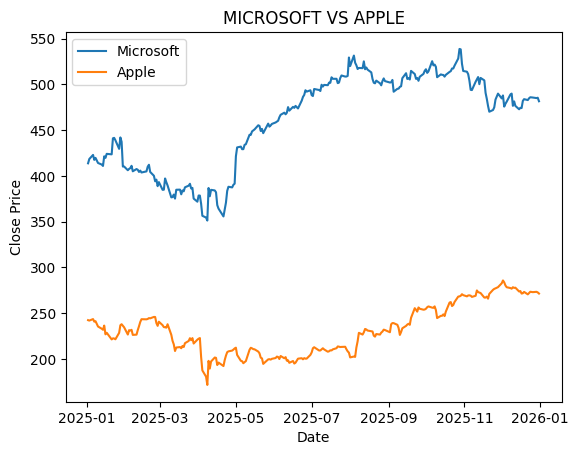

In [98]:
plt.plot(df1.index, df1['Close']['MSFT'], label='Microsoft')
plt.plot(df['Close']['AAPL'], label='Apple')
plt.title('MICROSOFT VS APPLE')
plt.xlabel('Date')
plt.legend()
plt.ylabel('Close Price')
plt.show()

In [81]:
# 1) Off the two stocks, Microsoft and Apple, Apple had the higher volume
#2) Microsoft had a higher volatility than Apple
#3) Apple's stocks saw constancy compared to Microsoft's stocks, which means that the price change in Microsoft's stocks was comparatively more than Apple's Stocks

In [82]:
import yfinance as yf
df2 = yf.download(['AAPL' , 'MSFT' , 'TCS.NS'], start='2025-01-01', end = '2026-01-01')
df2

/tmp/ipykernel_1907/778815087.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df2 = yf.download(['AAPL' , 'MSFT' , 'TCS.NS'], start='2025-01-01', end = '2026-01-01')
[*********************100%***********************]  3 of 3 completed


Price            Close                                 High              \
Ticker            AAPL        MSFT       TCS.NS        AAPL        MSFT   
Date                                                                      
2025-01-01         NaN         NaN  3851.036621         NaN         NaN   
2025-01-02  242.301910  413.672638  3910.312744  247.518580  421.074847   
2025-01-03  241.815018  418.386719  3839.283691  242.629804  419.058739   
2025-01-06  243.444626  422.833954  3834.695557  245.759836  429.228102   
2025-01-07  240.672333  417.418182  3772.235596  243.991125  425.601107   
...                ...         ...          ...         ...         ...   
2025-12-24  273.302216  485.856323  3216.133789  274.919206  486.991284   
2025-12-26  272.893005  485.547729  3178.342529  274.859353  485.955915   
2025-12-29  273.252350  484.940430  3150.725586  273.851213  486.184888   
2025-12-30  272.573547  485.318756  3146.171631  273.571693  487.508984   
2025-12-31  271.355835  481.475861  3106.829834  273.172467  485.975841   

Price                           Low                                 Open  \
Ticker           TCS.NS        AAPL        MSFT       TCS.NS        AAPL   
Date                                                                       
2025-01-01  3871.216583         NaN         NaN  3825.752685         NaN   
2025-01-02  3917.101888  240.284799  409.986387  3836.521957  247.349646   
2025-01-03  3914.245469  240.354349  414.621389  3832.166934  241.815018   
2025-01-06  3885.871561  241.656050  420.491744  3807.913464  242.759004   
2025-01-07  3877.163029  239.817792  415.866582  3756.550333  241.437433   
...                 ...         ...         ...          ...         ...   
2025-12-24  3223.982839  271.695216  482.680464  3193.943626  271.834940   
2025-12-26  3217.102804  272.353998  483.805488  3170.396720  273.651606   
2025-12-29  3186.094334  271.844961  482.033362  3142.392033  272.184327   
2025-12-30  3166.230026  271.775043  483.347524  3139.097833  272.304059   
2025-12-31  3145.396355  271.246054  481.157272  3099.368528  272.553622   

Price                                    Volume                         
Ticker            MSFT       TCS.NS        AAPL        MSFT     TCS.NS  
Date                                                                    
2025-01-01         NaN  3834.133720         NaN         NaN   763161.0  
2025-01-02  420.541170  3858.106569  55740700.0  16896500.0  1720835.0  
2025-01-03  416.143313  3914.245469  40244100.0  16662900.0  1791953.0  
2025-01-06  422.982189  3844.528109  45045600.0  20573600.0  2085593.0  
2025-01-07  423.970458  3853.377706  40856000.0  18139100.0  2669054.0  
...                ...          ...         ...         ...        ...  
2025-12-24  483.526701  3201.695681  17910600.0   5855900.0  1367708.0  
2025-12-26  484.552163  3210.416751  21521800.0   8842200.0  1176664.0  
2025-12-29  482.710340  3178.342280  23715200.0  10893400.0  2079473.0  
2025-12-30  483.775610  3149.272406  22139600.0  13944500.0  2807593.0  
2025-12-31  485.677152  3139.582314  27293600.0  15601600.0  3362634.0  

[260 rows x 15 columns]

In [89]:
print("Avg Daily returns of Apple:",round(df2['Close']['AAPL'].pct_change().mean(),5))
print("Std Daily returns of Apple:",round(df2['Close']['AAPL'].pct_change().std(),5))

Avg Daily returns of Apple: 0.00064
Std Daily returns of Apple: 0.02009


/tmp/ipykernel_1907/61702265.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  print("Avg Daily returns of Apple:",round(df2['Close']['AAPL'].pct_change().mean(),5))
/tmp/ipykernel_1907/61702265.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  print("Std Daily returns of Apple:",round(df2['Close']['AAPL'].pct_change().std(),5))


In [90]:
print("Avg Daily returns of Microsoft:",round(df2['Close']['MSFT'].pct_change().mean(),5))
print("Std Daily returns of Microsoft:",round(df2['Close']['MSFT'].pct_change().std()),5)

Avg Daily returns of Microsoft: 0.0007
Std Daily returns of Microsoft: 0 5


/tmp/ipykernel_1907/4013584666.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  print("Avg Daily returns of Microsoft:",round(df2['Close']['MSFT'].pct_change().mean(),5))
/tmp/ipykernel_1907/4013584666.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  print("Std Daily returns of Microsoft:",round(df2['Close']['MSFT'].pct_change().std()),5)


In [91]:
print("Avg Daily returns of TCS:",round(df2['Close']['TCS.NS'].pct_change().mean(),5))
print("Std Daily returns of TCS:",round(df2['Close']['TCS.NS'].pct_change().std(),5))

Avg Daily returns of TCS: -0.00075
Std Daily returns of TCS: 0.01224


/tmp/ipykernel_1907/1279930654.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  print("Avg Daily returns of TCS:",round(df2['Close']['TCS.NS'].pct_change().mean(),5))
/tmp/ipykernel_1907/1279930654.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  print("Std Daily returns of TCS:",round(df2['Close']['TCS.NS'].pct_change().std(),5))


In [34]:
daily_returns_matrix = pd.DataFrame({
    'AAPL': df2['Close']['AAPL'].pct_change(fill_method=None),
    'MSFT': df2['Close']['MSFT'].pct_change(fill_method=None),
    'TCS.NS': df2['Close']['TCS.NS'].pct_change(fill_method=None)
})
daily_returns_matrix.dropna(inplace=True)
daily_returns_matrix

,AAPL,MSFT,TCS.NS
Date,,,
2025-01-03,-0.002009,0.011396,-0.018165
2025-01-06,0.006739,0.010629,-0.001195
2025-01-07,-0.011388,-0.012808,-0.016288
2025-01-08,0.002023,0.005185,0.019884
2025-01-13,-0.010344,-0.004201,0.005966
...,...,...,...
2025-12-24,0.005324,0.002403,0.002719
2025-12-26,-0.001497,-0.000635,-0.011751
2025-12-29,0.001317,-0.001251,-0.008689


In [92]:
corr_matrix = daily_returns_matrix.corr()
corr_matrix

,AAPL,MSFT,TCS.NS
AAPL,1.000000,0.526750,0.081584
MSFT,0.526750,1.000000,0.136866
TCS.NS,0.081584,0.136866,1.000000


In [36]:
#According to the correlation matrix, AAPL and MSFT are related closely
#This means that Microsoft and Apple show same trends in daily return, the amount of high and low they go and in overall volatility
#TCS might have behaved differently from Apple and Microsoft due to its lower volume and lower volatility fluctuation

In [95]:
risk_free_rate = 0.0001
apple_sharpe_ratio = round((daily_returns_matrix['AAPL'].mean() - risk_free_rate) / daily_returns_matrix['AAPL'].std(),5)
microsoft_sharpe_ratio = round((daily_returns_matrix['MSFT'].mean() - risk_free_rate) / daily_returns_matrix['MSFT'].std(),5)
tcs_sharpe_ratio = round((daily_returns_matrix['TCS.NS'].mean() - risk_free_rate) / daily_returns_matrix['TCS.NS'].std(),5)
print("Apple Sharpe Ratio:",apple_sharpe_ratio)
print("Microsoft Sharpe Ratio:",microsoft_sharpe_ratio)
print("TCS Sharpe Ratio:",tcs_sharpe_ratio)


Apple Sharpe Ratio: 0.04797
Microsoft Sharpe Ratio: 0.02262
TCS Sharpe Ratio: -0.07089


In [97]:
#Apple and then Microsoft had the best risk-adjusted return
# This means that the company prospered better than its competitors even is crisis times



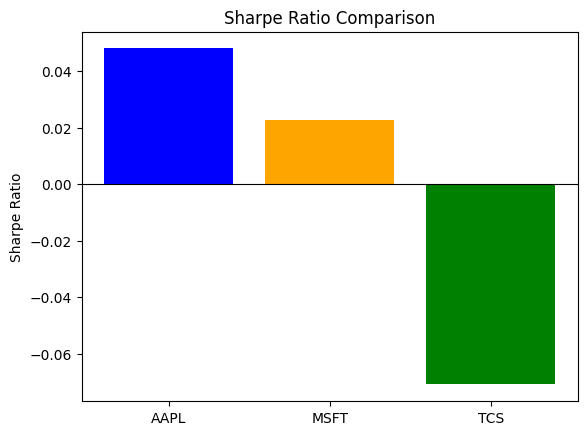

In [96]:
stocks = ['AAPL', 'MSFT', 'TCS']
sharpes = [apple_sharpe_ratio, microsoft_sharpe_ratio, tcs_sharpe_ratio]

plt.bar(stocks, sharpes, color=['blue','orange','green'])
plt.title('Sharpe Ratio Comparison')
plt.ylabel('Sharpe Ratio')
plt.axhline(0, color='black', linewidth=0.8)  # adds a zero line — important when one value is negative
plt.show()

Among the three stocks, TCS delivered the highest absolute price growth in 2025. Microsoft exhibited the highest volatility measured by standard deviation of daily returns, indicating greater price fluctuation and therefore higher risk for investors. The correlation analysis revealed that AAPL and MSFT move in moderate tandem, reflecting their shared exposure to US market sentiment and the technology sector, while TCS showed near-zero correlation with both, driven by its listing on the Indian NSE and sensitivity to domestic macroeconomic factors. Despite Microsoft's higher volatility, Apple delivered the best risk-adjusted return as measured by the Sharpe Ratio, meaning it generated more return per unit of risk taken. Future extensions of this analysis could include predictive modelling of stock prices using machine learning and portfolio optimisation to identify the ideal allocation across these three assets.
